In [1]:
import numpy as np
import pandas as pd
import data_clean_utils
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
%pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.

In [3]:
import dagshub
dagshub.init(repo_owner='Anubhavspeaks01', repo_name='swiggy-delivery-time-prediction', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b0bb3b59-782d-49be-9f9a-0de9c6a53167&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e606dc13f2728bce36f7bf225cb197a58aa8d3a4b4cfd8864e140fca117b7961




Accessing as Anubhavspeaks01

Initialized MLflow to track repo "Anubhavspeaks01/swiggy-delivery-time-prediction"

Repository Anubhavspeaks01/swiggy-delivery-time-prediction initialized!

In [4]:
import mlflow

In [5]:
# set the tracking server

mlflow.set_tracking_uri("https://dagshub.com/Anubhavspeaks01/swiggy-delivery-time-prediction.mlflow")

In [6]:
# mlflow experiment

mlflow.set_experiment("Exp 6 - Final Estimator")

2026/04/15 08:15:16 INFO mlflow.tracking.fluent: Experiment with name 'Exp 6 - Final Estimator' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/933d47c25f564d468432250bfd9978a0', creation_time=1776240917023, experiment_id='4', last_update_time=1776240917023, lifecycle_stage='active', name='Exp 6 - Final Estimator', tags={}, trace_location=None, workspace='default'>

In [7]:
from sklearn import set_config

set_config(transform_output="pandas")

In [8]:
# load the data

df = pd.read_csv('swiggy.csv')

df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18545,0x1f94,HYDRES05DEL02,36,4.6,17.433809,78.386744,17.483809,78.436744,03-03-2022,21:55:00,22:10:00,conditions Fog,Jam,0,Meal,motorcycle,0,No,Metropolitian,(min) 28
18546,0x65fd,PUNERES16DEL02,33,4.8,18.536718,73.830327,18.616719,73.910327,16-03-2022,19:25:00,19:30:00,conditions Windy,Jam,0,Drinks,motorcycle,0,No,Metropolitian,(min) 35
18547,0x6b50,MUMRES15DEL01,26,4.9,19.176269,72.836721,19.246269,72.906721,18-03-2022,23:00:00,23:10:00,conditions Cloudy,Low,0,Buffet,motorcycle,0,No,Metropolitian,(min) 23
18548,0x71f,CHENRES06DEL02,NaN,NaN,13.054347,80.257221,13.184347,80.387221,08-03-2022,NaN,18:55:00,conditions Sandstorms,Medium,1,Drinks,scooter,0,No,Metropolitian,(min) 15


In [9]:
data_clean_utils.perform_data_cleaning(df)

Data cleaned and saved successfully!


In [10]:
# load the cleaned data

df = pd.read_csv('swiggy_cleaned.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18512,HYDRES05DEL02,36.0,4.6,17.433809,78.386744,17.483809,78.436744,2022-03-03,fog,jam,...,HYD,3,3,thursday,0,15.0,21.0,night,7.683698,medium
18513,PUNERES16DEL02,33.0,4.8,18.536718,73.830327,18.616719,73.910327,2022-03-16,windy,jam,...,PUNE,16,3,wednesday,0,5.0,19.0,evening,12.257003,long
18514,MUMRES15DEL01,26.0,4.9,19.176269,72.836721,19.246269,72.906721,2022-03-18,cloudy,low,...,MUM,18,3,friday,0,10.0,23.0,night,10.705623,long
18515,CHENRES06DEL02,NaN,NaN,13.054347,80.257221,13.184347,80.387221,2022-03-08,sandstorms,medium,...,CHEN,8,3,tuesday,0,NaN,NaN,NaN,20.177913,very_long


In [11]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [12]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18512,36.0,4.6,fog,jam,0,meal,motorcycle,0.0,no,metropolitian,28,0,15.0,night,7.683698,medium
18513,33.0,4.8,windy,jam,0,drinks,motorcycle,0.0,no,metropolitian,35,0,5.0,evening,12.257003,long
18514,26.0,4.9,cloudy,low,0,buffet,motorcycle,0.0,no,metropolitian,23,0,10.0,night,10.705623,long
18515,NaN,NaN,sandstorms,medium,1,drinks,scooter,0.0,no,metropolitian,15,0,NaN,NaN,20.177913,very_long


In [13]:
# check for missing values

df.isna().sum()

,0
age,714
ratings,736
weather,220
traffic,214
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,390
festival,79
city_type,474


In [14]:
# check for duplicates

df.duplicated().sum()

np.int64(0)

<Axes: >

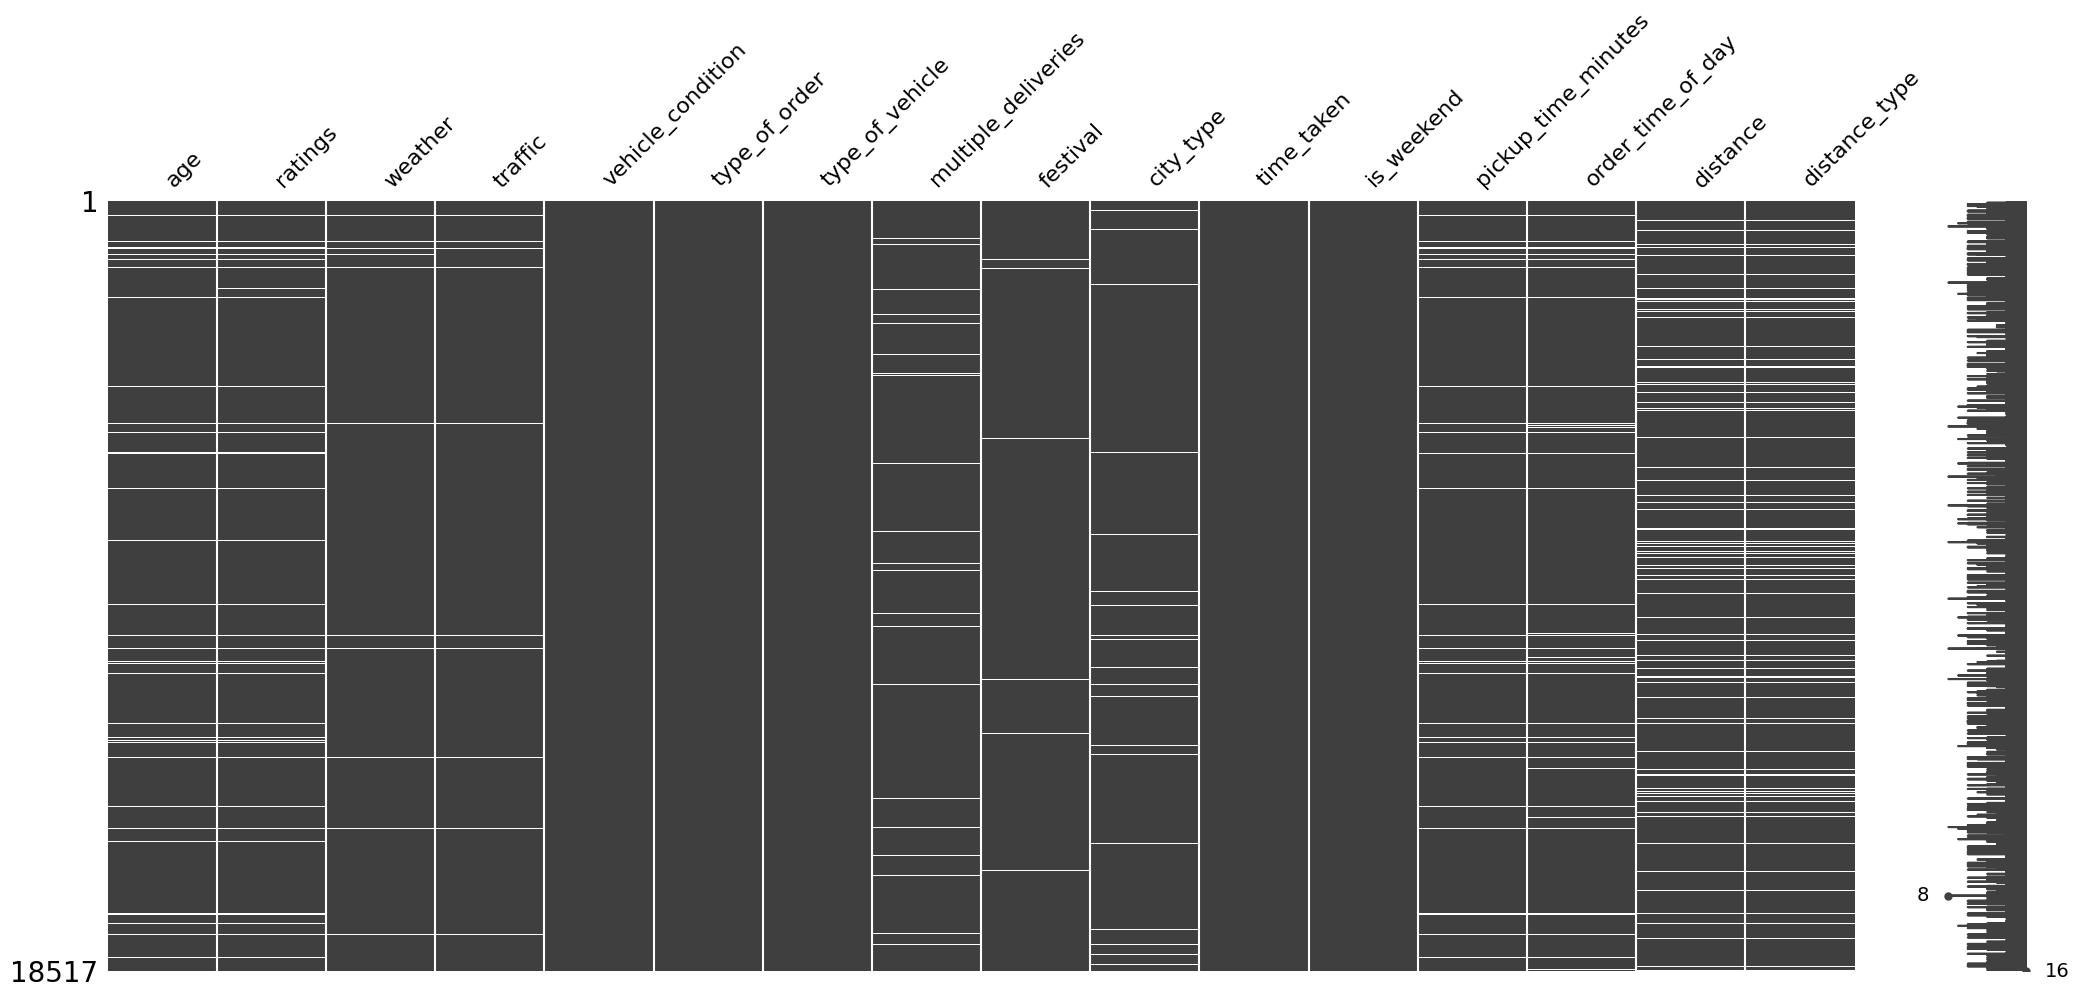

In [15]:
import missingno as msno

msno.matrix(df)

In [16]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [17]:
temp_df = df.copy().dropna()

In [18]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18510,35.0,4.8,cloudy,low,0,snack,motorcycle,0.0,no,metropolitian,0,5.0,morning,3.116249,short
18512,36.0,4.6,fog,jam,0,meal,motorcycle,0.0,no,metropolitian,0,15.0,night,7.683698,medium
18513,33.0,4.8,windy,jam,0,drinks,motorcycle,0.0,no,metropolitian,0,5.0,evening,12.257003,long
18514,26.0,4.9,cloudy,low,0,buffet,motorcycle,0.0,no,metropolitian,0,10.0,night,10.705623,long


In [19]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (12321, 15)
The shape of test data is (3081, 15)


In [21]:
# missing values in train data

X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [22]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [23]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [24]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


np.float64(0.0)

In [25]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [26]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [27]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [28]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [29]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [30]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['medium' 'high' 'jam' 'low']
distance_type ['medium' 'short' 'very_long' 'long']


In [31]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [33]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [34]:
# do data preprocessing

X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [35]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
1478,0.631579,0.84,0.993103,0.313178,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,1.0
7119,0.684211,0.92,0.993103,0.240063,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0,1.0
520,0.157895,0.84,1.000000,0.164538,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2,1.0
674,0.736842,0.84,1.000000,0.389164,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0,1.0
3651,1.000000,0.84,1.000000,0.764945,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,3.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6305,0.684211,0.84,0.993103,0.545190,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,0,1.0
16153,0.842105,0.84,0.996552,0.003435,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,1.0
6548,0.842105,0.88,0.996552,0.555146,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1,1.0
1045,0.947368,0.96,0.996552,0.004483,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0,1.0


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import StackingRegressor

In [38]:
# build the best models

best_rf_params = {'n_estimators': 479,
 'criterion': 'squared_error',
 'max_depth': 17,
 'max_features': None,
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_samples': 0.6603673526197067}

best_lgbm_params = {'n_estimators': 154,
 'max_depth': 27,
 'learning_rate': 0.22234435854395157,
 'subsample': 0.7592213724048168,
 'min_child_weight': 20,
 'min_split_gain': 0.004604680609280751,
 'reg_lambda': 97.81002379097947}

best_rf = RandomForestRegressor(**best_rf_params)
best_lgbm = LGBMRegressor(**best_lgbm_params)

lr = LinearRegression()

In [39]:
# build the stacking regressor

stacking_reg = StackingRegressor(estimators=[("rf",best_rf),
                                            ("lgbm",best_lgbm)],
                                final_estimator=lr,
                                cv=5,n_jobs=-1)

# build transformed regressor

model = TransformedTargetRegressor(regressor=stacking_reg,
                                    transformer=pt)

# train the model
model.fit(X_train_trans,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(


TransformedTargetRegressor(regressor=StackingRegressor(cv=5,
                                                       estimators=[('rf',
                                                                    RandomForestRegressor(max_depth=17,
                                                                                          max_features=None,
                                                                                          max_samples=0.6603673526197067,
                                                                                          min_samples_leaf=2,
                                                                                          min_samples_split=9,
                                                                                          n_estimators=479)),
                                                                   ('lgbm',
                                                                    LGBMRegressor(learning_rate=0.22234435854395157,
                                                                                  max_depth=27,
                                                                                  min_child_weight=20,
                                                                                  min_split_gain=0.004604680609280751,
                                                                                  n_estimators=154,
                                                                                  reg_lambda=97.81002379097947,
                                                                                  subsample=0.7592213724048168))],
                                                       final_estimator=LinearRegression(),
                                                       n_jobs=-1),
                           transformer=PowerTransformer())

In [40]:
# get the train and test predictions

y_train_pred = model.predict(X_train_trans)
y_test_pred = model.predict(X_test_trans)

# calculate the train and test mae

train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test,y_test_pred)

# calculate the r2 scores

train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test,y_test_pred)

# calculate cross val scores

cv_scores = cross_val_score(model,
                            X_train_trans,
                            y_train,cv=3,
                            scoring="neg_mean_absolute_error",
                            n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [41]:
-cv_scores

array([3.22713034, 3.17832573, 3.22168345])

In [42]:
# log with mlflow

with mlflow.start_run():
    # set tags
    mlflow.set_tag("model","stacking regressor")

    # log parameters
    mlflow.log_params(stacking_reg.get_params())

    # log metrics
    mlflow.log_metric("train_mae",train_mae)
    mlflow.log_metric("test_mae",test_mae)
    mlflow.log_metric("train_r2",train_r2)
    mlflow.log_metric("test_r2",test_r2)
    mlflow.log_metric("cv_score",-(cv_scores.mean()))

    # log the stacking regressor
    mlflow.sklearn.log_model(stacking_reg,"model")

2026/04/15 08:24:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 08:24:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run gentle-shrimp-143 at: https://dagshub.com/Anubhavspeaks01/swiggy-delivery-time-prediction.mlflow/#/experiments/4/runs/cfad9ee0ecaf499d8880727b52286015
🧪 View experiment at: https://dagshub.com/Anubhavspeaks01/swiggy-delivery-time-prediction.mlflow/#/experiments/4
